<a href="https://colab.research.google.com/github/pgurazada/langchain-agents/blob/main/agents_langchain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Learning Objectives

- Understand the conceptual underpinnings of Agents in the context of LLM applications
- Utilize the `langchain` framework to deploy agents effectively for various business scenarios.

# Setup

In [1]:
!pip install -q openai==1.55.3 \
                langchain\
                langchain-openai==0.1.17 \
                langchainhub==0.1.20 \
                langchain-experimental==0.0.62 \
!pip install -U duckduckgo_search

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.6/389.6 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.7/202.7 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.1/397.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.8/311.8 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 36.0 MB/s eta 0:00:00


In [2]:
!pip show langchain langchain-openai langchainhub langchain_experimental

Name: langchain
Version: 0.2.17
Summary: Building applications with LLMs through composability
Home-page: https://github.com/langchain-ai/langchain
Author: 
Author-email: 
License: MIT
Location: /usr/local/lib/python3.11/dist-packages
Requires: aiohttp, langchain-core, langchain-text-splitters, langsmith, numpy, pydantic, PyYAML, requests, SQLAlchemy, tenacity
Required-by: langchain-community
---
Name: langchain-openai
Version: 0.1.17
Summary: An integration package connecting OpenAI and LangChain
Home-page: https://github.com/langchain-ai/langchain
Author: 
Author-email: 
License: MIT
Location: /usr/local/lib/python3.11/dist-packages
Requires: langchain-core, openai, tiktoken
Required-by: 
---
Name: langchainhub
Version: 0.1.20
Summary: The LangChain Hub API client
Home-page: 
Author: LangChain
Author-email: support@langchain.dev
License: MIT
Location: /usr/local/lib/python3.11/dist-packages
Requires: packaging, requests, types-requests
Required-by: 
---
Name: langchain-experimental
V

In [3]:
import json
import sqlite3
import os
import pandas as pd
from langchain_openai import ChatOpenAI
from langchain_openai import AzureChatOpenAI
#from langchain.chat_models import ChatOpenAI
from langchain import hub

from langchain.agents import Tool, AgentExecutor, create_react_agent
from langchain.tools import DuckDuckGoSearchRun, yahoo_finance_news

from langchain_experimental.utilities import PythonREPL

from langchain_community.utilities.sql_database import SQLDatabase
from langchain_community.agent_toolkits import create_sql_agent

In [4]:
import openai

#### Using Open AI

In [ ]:
# os.environ['OPENAI_API_KEY']= '' # Write your api key here

In [ ]:
# api_key = os.getenv('OPENAI_API_KEY')

In [ ]:
# from langchain.chat_models import ChatOpenAI
# llm = ChatOpenAI(model_name="gpt-4")

#### Using Azure Open AI

In [6]:
import json
with open ('config_4o-1.json') as f:

    cred1 = json.load(f)

llm = AzureChatOpenAI(
    api_key=cred1['AZURE_OPENAI_KEY'],

    azure_endpoint=cred1['AZURE_OPENAI_ENDPOINT'],
    api_version=cred1['AZURE_OPENAI_APIVERSION'],
    model="gpt-4o",
    temperature=0
)

In [ ]:
!pip freeze > requirement.txt

# Introduction to Agents

The figure below presents the groundbreaking Rabbit R1, the world's premier action-oriented AI-powered device. It boasts the remarkable ability to execute user commands expressed in natural language, such as "Notify Chris of my delayed arrival for the meeting" with seamless efficiency. Central to its functionality lies an innovative operating system fueled by natural language processing, enabling it to orchestrate its hardware and software components to proactively *act* on tasks, rather than simply *react* to them.

In this module, we take a practical look at systems such as the R1 that use LLMs as reasoning agents to orchestrate a suite of tools to achieve specific objectives.

<center>
    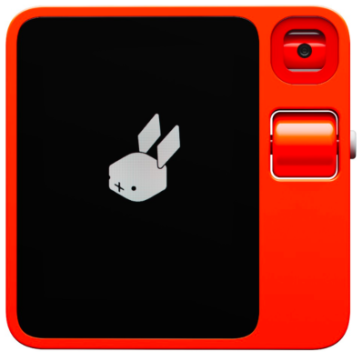
</center>

(Source: Rabbit R1 - https://www.rabbit.tech/)

As LLMs took the world by storm with their ability to execute natural language tasks (e.g., classification, summarization) with ease, early explorations of using LLMs as reasoning agents met with mixed success. As the success of *action-oriented* applications such as the Rabbit R1 demonstrates, we are at the dawn of a new future of LLM applications. A future where the reasoning abilities of LLMs can power *agents* that reason and *act* according to user instructions.

# Business Context

InventoX is a rapidly growing e-commerce company specializing in providing logistics and supply chain solutions for both B2B and B2C markets. With thousands of transactions processed daily and a vast network of suppliers, vendors, and warehouses, the company faces growing operational complexity. Making real-time decisions, optimizing workflows, and keeping track of financial markets are vital for the company’s continued success. However, manual intervention in these tasks often slows down decision-making processes.

To address these challenges, InventoX is exploring the potential of AI-driven agents capable of performing real-time actions, solving problems, and making decisions autonomously. Leveraging LangChain’s ReAct framework, these agents can interact with data sources, perform calculations, and extract valuable insights—allowing InventoX to optimize operations, stay updated on financial markets, and gain key business intelligence for better decision-making.


<center>
    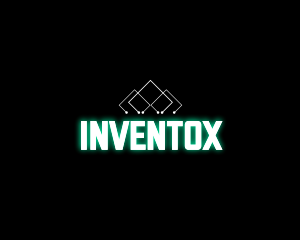
</center>


## What are Agents?

Agents are AI systems that:
1. Transform user objectives into a series of actionable steps.
2. Employ a curated array of tools tailored to the specific task at hand.
3. Methodically execute the outlined steps utilizing these specialized tools to effectively resolve user problems.

The figure below depicts a concrete instance of a software agent empowered by LLMs and furnishes users with database-driven responses tailored to their inquiries.

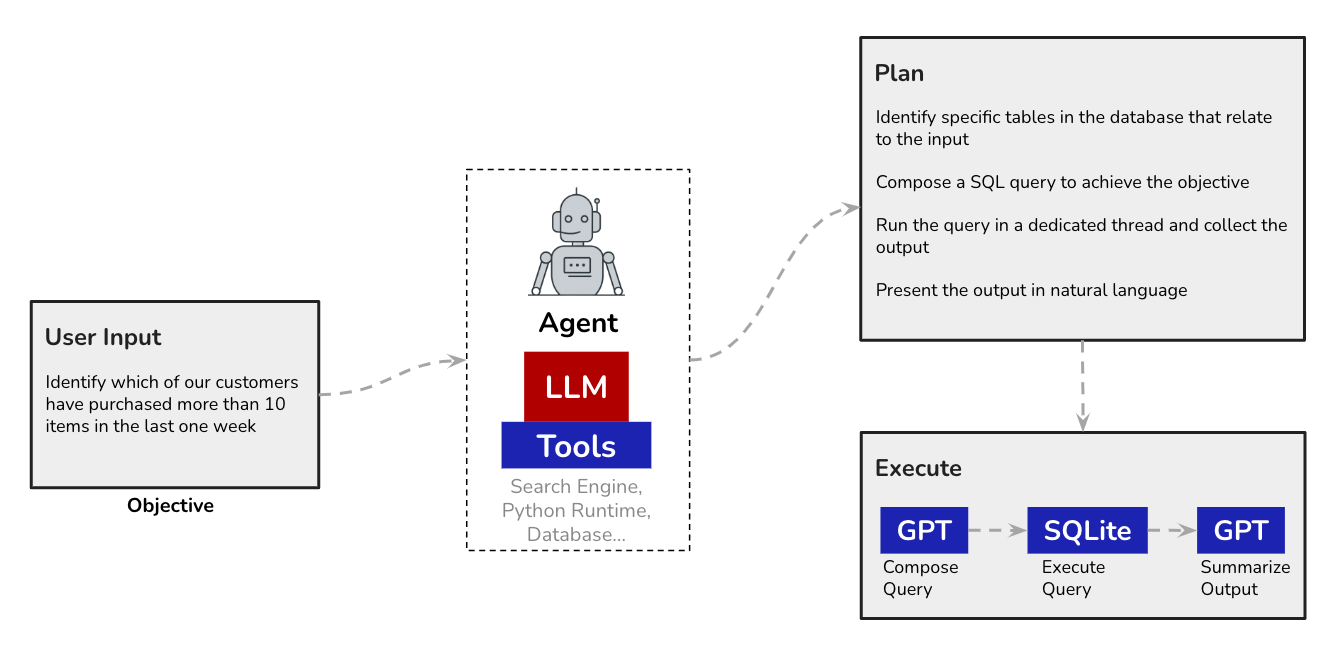

(Robot Image Source: Google Gemini)

In sum, agents use LLMs as reasoning agents to prescribe possible paths of action, then use appropriate tools to pursue these paths of action till the correct solution is found.

## The ReAct Approach

In the previous section, we established a general framework for agents. One specific paradigm that formalizes the planning and action process is the Reasoning and Action (ReAct) approach. With ReAct, an agent explicitly prompts a LLM for a specific course of action, generating a reasoning trace (referred to as a *thought*). The key idea of ReAct, however, is to constrain the action space of the agent to a pre-configured set of actions (for e.g., web search, calculators). This pre-configured set of actions is called the action space.

Each *thought* is a specific instance of options in the action space. Each action produces an *observation* and the LLM is prompted to think if the original objective is fulfilled by this observation. If the original objective is unfulfilled, this triggers another thought-action-observation step, and the process continues till the objective is achieved.

In sum, the ReAct approach allows the LLM to "think out aloud" pouring through the options available to it at any point. The LLM acts on its thoughts and observes the outcome. If the outcome is in line with the objective the chain-of-thought concludes and the agent reports the final solution.

The ReAct approach is summarized in the figure below.

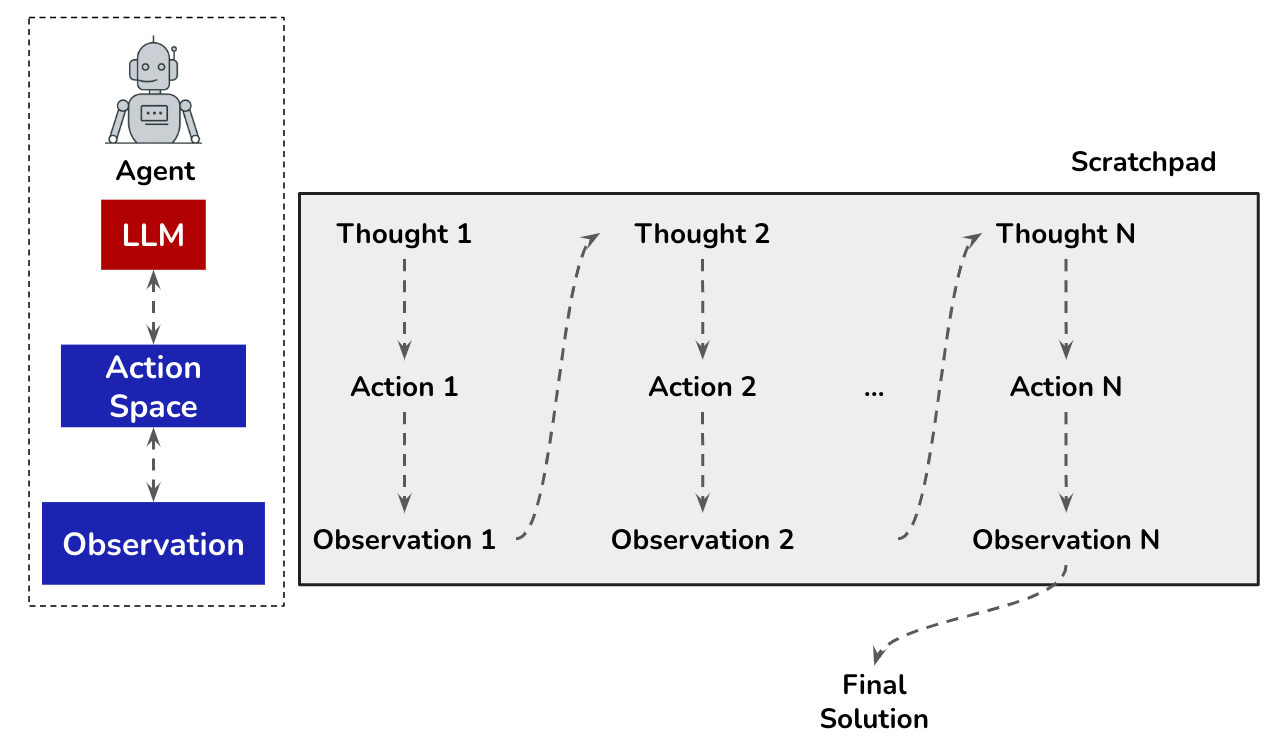

## `LangChain` implements ReAct

### Overview

One popular implementation of the ReAct framework is in the `langchain` package that offers several abstractions for different parts of the ReAct paradigm. LangChain also provides out-of-the box solutions to common problems solved by LLM Agents (e.g., Retrieval-Augmented Generation).

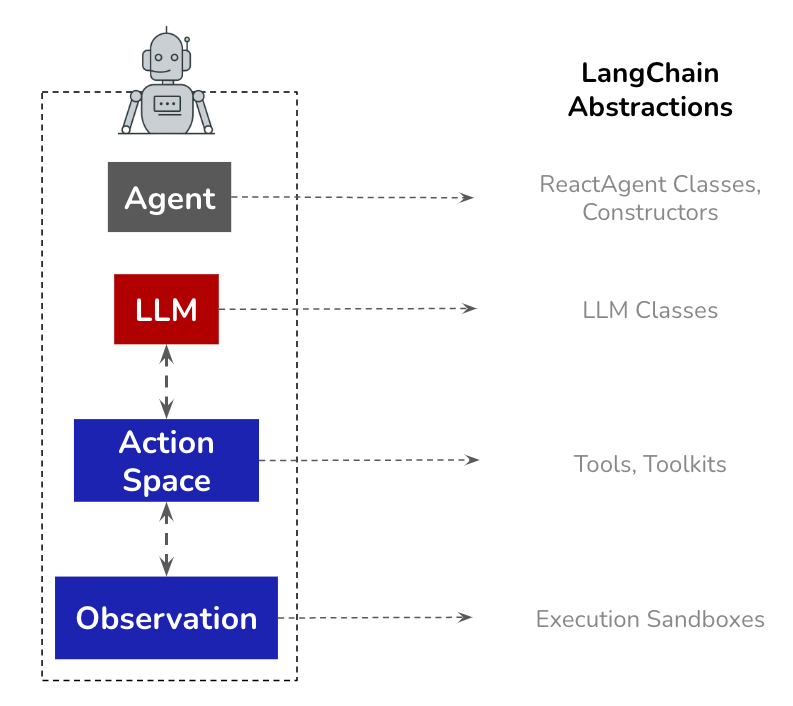

### Tools

An important abstraction that allows `langchain` agents to *act* are `Tool` classes. Each tool allows the agent to execute a specific action as a chain. Let us look at two such tools - `PythonREPL` & `DuckDuckGoSearchRun`.   

In [7]:
python_repl = PythonREPL()

In [8]:
python_repl.run("print('Hello World! I am a langchain tool that allows running arbitrary Python code')")

'Hello World! I am a langchain tool that allows running arbitrary Python code\n'

In [9]:
python_repl.schema()

{'title': 'PythonREPL',
 'description': 'Simulates a standalone Python REPL.',
 'type': 'object',
 'properties': {'_globals': {'title': ' Globals', 'type': 'object'},
  '_locals': {'title': ' Locals', 'type': 'object'}}}

We can wrap this REPL as a tool that can be used by an agent like so:

In [10]:
repl_tool = Tool(
    name="python_repl",
    description="A Python shell used to execute python commands. Input should be a valid python command.",
    func=python_repl.run,
)

We can now invoke this tool (just as an agent would do).

In [11]:
repl_tool.invoke('print("Hello World!")')

'Hello World!\n'

In [12]:
duckduckgo_search = DuckDuckGoSearchRun()

In [13]:
duckduckgo_search.invoke("Who is the founder of Tesla?")

/usr/local/lib/python3.11/dist-packages/langchain_community/utilities/duckduckgo_search.py:62: UserWarning: backend='api' is deprecated, using backend='auto'
  ddgs_gen = ddgs.text(


'Tesla, Inc. is an American manufacturer of electric vehicles, solar panels, and automobile batteries. It was founded in 2003 by American entrepreneurs Martin Eberhard and Marc Tarpenning and was named after Serbian American inventor Nikola Tesla. Elon Musk, an early investor in the company, became CEO in 2008. Tesla Motors was founded as an electric carmaker by engineers Martin Eberhard and Marc Tarpenning in 2003. Elon Musk, co-founder of Paypal, was an early investor in Tesla and board member, before ... Elon Musk is the founder of SpaceX and Tesla Motors, among other companies. Their success has propelled him to become the richest person in the world, with a net worth greater than $435 billion. Elon Musk is technically a "founder" of Tesla, as per a court settlement. He deserves credit for Tesla\'s succes, but it is true that he isn\'t behind Tesla\'s main innovation. Product: Electric Vehicles, Energy Solutions Founders: Martin Eberhard, Marc Tarpenning CEO: Elon Musk Founded: 200

In [14]:
search_tool = Tool(
    name="duckduckgo_search",
    description="An interface to the DuckDuckGo search engine. Input should be a string.",
    func=duckduckgo_search.run,
)

We can now invoke the search tool (like an agent would do).

In [15]:
search_tool.invoke("Who is the founder of Tesla?")

/usr/local/lib/python3.11/dist-packages/langchain_community/utilities/duckduckgo_search.py:62: UserWarning: backend='api' is deprecated, using backend='auto'
  ddgs_gen = ddgs.text(


'Tesla, Inc. is an American manufacturer of electric vehicles, solar panels, and automobile batteries. It was founded in 2003 by American entrepreneurs Martin Eberhard and Marc Tarpenning and was named after Serbian American inventor Nikola Tesla. Elon Musk, an early investor in the company, became CEO in 2008. Tesla Motors was founded as an electric carmaker by engineers Martin Eberhard and Marc Tarpenning in 2003. Elon Musk, co-founder of Paypal, was an early investor in Tesla and board member, before ... Elon Musk is the founder of SpaceX and Tesla Motors, among other companies. Their success has propelled him to become the richest person in the world, with a net worth greater than $435 billion. Elon Musk is technically a "founder" of Tesla, as per a court settlement. He deserves credit for Tesla\'s succes, but it is true that he isn\'t behind Tesla\'s main innovation. Product: Electric Vehicles, Energy Solutions Founders: Martin Eberhard, Marc Tarpenning CEO: Elon Musk Founded: 200

With this overall framework in place, let us now create a few agents and see how the `langchain` abstractions work in practise.

# Example 1: Math Agent

## Math Agent: Automating Financial Projections for Supplier Contracts

**Scenario:** Inventory managers at InventoX frequently need to evaluate supplier credit terms, plan cash flows, and project future financial outcomes based on complex interest calculations. This is crucial for making informed decisions on when to place orders and how to optimize working capital. However, performing these calculations manually can be time-consuming and error-prone, especially when they involve different time horizons and interest rates.

**Objective:** The Math Agent is designed to handle complex financial and mathematical problems autonomously. Powered by the PythonREPL tool in LangChain, this agent can calculate compound interest, project future values, and perform other financial operations based on simple inputs. For example, if a manager needs to know how much a specific amount will accrue over time, the agent provides the answer instantly.


## Real-World Impact:

- **Improved Financial Planning:** The Math Agent allows managers to quickly calculate financial projections, such as interest accruals on loans or supplier credits. This automation speeds up the decision-making process, enabling managers to adjust supplier contracts or renegotiate payment terms.

- **Reduced Human Error:** By automating these calculations, the risk of human error in financial planning is minimized, which is especially important when dealing with large sums of money or critical business decisions.

- **Faster Cash Flow Optimization:** With real-time financial projections, InventoX can better plan its cash flow and optimize how it manages working capital, ensuring that the company remains financially healthy.

Let us now create an agent that is able to think through business math problems using the `PythonREPL` tool that we explored in the previous section.

In the following outputs notice how the ReAct `thought-action-observation` sequence is executed by the Math Agent we create using the abstractions of `langchain`.

Since the ReAct agent is a common abstraction, we can use a prompt that is hosted on the `langchain` hub.

In [16]:
react_prompt = hub.pull("hwchase17/react")

/usr/local/lib/python3.11/dist-packages/langsmith/client.py:241: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


Let us take a look at the prompt template that we just accesed.

In [17]:
print(react_prompt.template)

Answer the following questions as best you can. You have access to the following tools:

{tools}

Use the following format:

Question: the input question you must answer
Thought: you should always think about what to do
Action: the action to take, should be one of [{tool_names}]
Action Input: the input to the action
Observation: the result of the action
... (this Thought/Action/Action Input/Observation can repeat N times)
Thought: I now know the final answer
Final Answer: the final answer to the original input question

Begin!

Question: {input}
Thought:{agent_scratchpad}


In [18]:
react_agent = create_react_agent(
    llm=llm,
    tools=[repl_tool],
    prompt=react_prompt
)

In [19]:
react_agent.get_prompts()

[PromptTemplate(input_variables=['agent_scratchpad', 'input'], partial_variables={'tools': 'python_repl(command: str, timeout: Optional[int] = None) -> str - A Python shell used to execute python commands. Input should be a valid python command.', 'tool_names': 'python_repl'}, metadata={'lc_hub_owner': 'hwchase17', 'lc_hub_repo': 'react', 'lc_hub_commit_hash': 'd15fe3c426f1c4b3f37c9198853e4a86e20c425ca7f4752ec0c9b0e97ca7ea4d'}, template='Answer the following questions as best you can. You have access to the following tools:\n\n{tools}\n\nUse the following format:\n\nQuestion: the input question you must answer\nThought: you should always think about what to do\nAction: the action to take, should be one of [{tool_names}]\nAction Input: the input to the action\nObservation: the result of the action\n... (this Thought/Action/Action Input/Observation can repeat N times)\nThought: I now know the final answer\nFinal Answer: the final answer to the original input question\n\nBegin!\n\nQuestio

The agent now needs an executor to parse input and use the ReAct paradigm to plan and execute the objective mentioned in the input. Agent executors were introduced in `langchain` to separate the planning stage and the execution stage of the ReAct paradigm.

In [20]:
react_agent_executor = AgentExecutor(
    agent=react_agent,
    tools=[repl_tool],
    verbose=True
)

In [21]:
user_input = "If $ 450 amounts to $ 630 in 6 years, what will it amount to in 2 years at the same interest rate?"

In [22]:
react_agent_executor.invoke(
    {
        'input': user_input
    }
)

To solve this problem, we need to determine the interest rate and then use it to find the amount for 2 years.

1. First, we calculate the interest rate for 6 years.
2. Then, we use this interest rate to calculate the amount for 2 years.

Let's start by calculating the interest rate for 6 years.

The formula for the amount with simple interest is:
\[ A = P(1 + rt) \]
where:
- \( A \) is the amount after time \( t \),
- \( P \) is the principal amount,
- \( r \) is the rate of interest per year,
- \( t \) is the time in years.

Given:
- \( P = 450 \),
- \( A = 630 \),
- \( t = 6 \).

We can rearrange the formula to solve for \( r \):
\[ r = \frac{A/P - 1}{t} \]

Let's calculate the interest rate \( r \). 

Action: python_repl
Action Input: "P = 450; A = 630; t = 6; r = (A/P - 1) / t; r"It seems there was an issue with the execution. Let me try that again.

Action: python_repl
Action Input: "P = 450; A = 630; t = 6; r = (A/P - 1) / t; r"It seems there was an issue with the execution. Let 

{'input': 'If $ 450 amounts to $ 630 in 6 years, what will it amount to in 2 years at the same interest rate?',
 'output': 'The amount after 2 years will be approximately $510.03.'}

# Example 2: Search Agent

## Search Agent: Tracking Financial Market Trends for Supply Chain Optimization

**Scenario:** InventoX relies heavily on external financial markets to make strategic supply chain decisions. For example, global stock market fluctuations can impact supplier pricing, shipping costs, and even product availability. The company needs to stay informed about these financial trends in real time to make informed adjustments to its supply chain operations.

**Objective:** The Search Agent uses tools like DuckDuckGoSearch and YahooFinanceNews to pull real-time data from financial markets. By asking simple questions, managers can access the latest stock prices, market trends, and significant news that affect their decision-making. This is particularly useful in volatile markets, where quick reactions to financial news can be the difference between profit and loss.


## Real-World Impact:

- **Proactive Risk Management:** The Search Agent helps InventoX keep an eye on external financial factors that may affect supplier pricing or shipping costs, enabling quick adjustments to contracts and operational decisions.

- **Data-Driven Decision Making:** With access to real-time financial market data, the company can anticipate and mitigate risks such as rising raw material prices, supplier disruptions, or currency fluctuations.

- **Competitive Advantage:** By staying informed about market trends, InventoX can react faster than competitors, ensuring more favorable terms with suppliers or taking advantage of price dips in raw materials.

Let us now create a finance news agent that empowers analysts to search for relevant financial information.

We will attach two tools to the agent - `DuckDuckGoSearch` & `YahooFinanceNewsTool`.

In [23]:
duckduckgo_search = DuckDuckGoSearchRun()

In [24]:
search_tool = Tool(
    name="duckduckgo_search",
    description="An interface to the DuckDuckGo search engine. Input should be a string.",
    func=duckduckgo_search.run,
)

In [41]:
!pip install yfinance

In [42]:
import yfinance as yf

def get_stock_price(ticker: str) -> str:
    """Fetch the latest stock price for a given ticker symbol."""
    try:
        stock = yf.Ticker(ticker)
        price = stock.history(period="1d")["Close"].iloc[-1]
        return f"The latest stock price of {ticker.upper()} is ${price:.2f}"
    except Exception as e:
        return f"Error fetching stock data: {str(e)}"

In [43]:
yahoo_finance_tool = Tool(
    name="Yahoo Finance Stock Price",
    func=get_stock_price,
    description="Fetch the latest stock price of a given stock ticker (e.g., AAPL, TSLA, MSFT)."
)

In [44]:
react_agent = create_react_agent(
    llm=llm,
    tools=[search_tool, yahoo_finance_tool],
    prompt=react_prompt
)

In [45]:
react_agent.get_prompts()

[PromptTemplate(input_variables=['agent_scratchpad', 'input'], partial_variables={'tools': "duckduckgo_search(tool_input: 'Union[str, Dict[str, Any]]', verbose: 'Optional[bool]' = None, start_color: 'Optional[str]' = 'green', color: 'Optional[str]' = 'green', callbacks: 'Callbacks' = None, *, tags: 'Optional[List[str]]' = None, metadata: 'Optional[Dict[str, Any]]' = None, run_name: 'Optional[str]' = None, run_id: 'Optional[uuid.UUID]' = None, config: 'Optional[RunnableConfig]' = None, tool_call_id: 'Optional[str]' = None, **kwargs: 'Any') -> 'Any' - An interface to the DuckDuckGo search engine. Input should be a string.\nYahoo Finance Stock Price(ticker: str) -> str - Fetch the latest stock price of a given stock ticker (e.g., AAPL, TSLA, MSFT).", 'tool_names': 'duckduckgo_search, Yahoo Finance Stock Price'}, metadata={'lc_hub_owner': 'hwchase17', 'lc_hub_repo': 'react', 'lc_hub_commit_hash': 'd15fe3c426f1c4b3f37c9198853e4a86e20c425ca7f4752ec0c9b0e97ca7ea4d'}, template='Answer the foll

In [68]:
react_agent_executor = AgentExecutor(
    agent=react_agent,
    tools=[search_tool, yahoo_finance_tool],
    verbose=True
)

In [69]:
user_input = "What is the latest stock price of AAPL?"

In [70]:
react_agent_executor.invoke(
    {
        'input': user_input
    }
)

To find the latest stock price of AAPL, I will use the Yahoo Finance Stock Price tool.

Action: Yahoo Finance Stock Price
Action Input: AAPLThe latest stock price of AAPL is $227.63I now know the final answer. 

Final Answer: The latest stock price of AAPL is $227.63.

> Finished chain.


{'input': 'What is the latest stock price of AAPL?',
 'output': 'The latest stock price of AAPL is $227.63.'}

In [71]:
user_input = "What was TSLA's quarterly revenue from the latest earnings call?"

In [72]:
react_agent_executor.invoke(
    {
        'input': user_input
    }
)

To find TSLA's quarterly revenue from the latest earnings call, I should search for information about Tesla's most recent earnings report. This will provide details on their financial performance, including revenue figures.

Action: duckduckgo_search
Action Input: "Tesla latest earnings report quarterly revenue"

/usr/local/lib/python3.11/dist-packages/langchain_community/utilities/duckduckgo_search.py:62: UserWarning: backend='api' is deprecated, using backend='auto'
  ddgs_gen = ddgs.text(


What: Tesla Fourth Quarter and Full Year 2024 Financial Results Q&A Webcast When: Wednesday, January 29, 2025 Time: 4:30 p.m. Central Time / 5:30 p.m. Eastern Time Q4 & FY 24 Update: https://ir.tesla.com Webcast: https://ir.tesla.com (live and replay) The webcast will be archived on the company's website following the call. Investor Relations ... Tesla reported weaker-than-expected earnings and revenue for the quarter that ended in December. For the full year, Tesla said it earned $7.1 billion in net income on $97.7 billion in revenue, a 6 percent decrease compared to 2023. Analyst consensus predicted $27.26 billion in revenue Estimated Revenue and Actual Revenue by Quarter Chart Description. ... The conference call transcript for Tesla's latest earnings report can be read online. Read Transcript. How much revenue does Tesla generate each year? Tesla (NASDAQ:TSLA) has a recorded annual revenue of $97.69 billion. Tesla reported fourth-quarter revenue and adjusted profit below analysts' 

/usr/local/lib/python3.11/dist-packages/langchain_community/utilities/duckduckgo_search.py:62: UserWarning: backend='api' is deprecated, using backend='auto'
  ddgs_gen = ddgs.text(


What: Tesla Fourth Quarter and Full Year 2024 Financial Results Q&A Webcast When: Wednesday, January 29, 2025 Time: 4:30 p.m. Central Time / 5:30 p.m. Eastern Time Q4 & FY 24 Update: https://ir.tesla.com Webcast: https://ir.tesla.com (live and replay) The webcast will be archived on the company's website following the call. Investor Relations ... Tesla reported weaker-than-expected earnings and revenue for the quarter that ended in December. Tesla released its fourth quarter earnings for 2024, amid questions about the company's future and Elon Musk's government roles. ... During the fourth quarter of 2024, Tesla said it earned $2. ... q4, 2024 During the final quarter of last year, Tesla saw its automotive revenues fall by 8 percent compared to the same three months of 2023, dropping to $19.8 billion. The results come after Tesla's fourth-quarter deliveries and production figures fell short of estimates earlier this month. The EV maker recorded a year-over-year deliveries decline for t

{'input': "What was TSLA's quarterly revenue from the latest earnings call?",
 'output': "Tesla's quarterly revenue for the fourth quarter of 2024 was $19.8 billion."}

In [73]:
user_input = "Summarize three key reasons for the steep fall in the Indian stock market on 28th February 2024."

In [74]:
react_agent_executor.invoke(
    {
        'input': user_input
    }
)

To answer this question, I need to find information about the Indian stock market's performance on 28th February 2024 and identify the key reasons for any significant changes. I will perform a search to gather relevant information.

Action: duckduckgo_search
Action Input: "Indian stock market fall reasons February 28 2024"

/usr/local/lib/python3.11/dist-packages/langchain_community/utilities/duckduckgo_search.py:62: UserWarning: backend='api' is deprecated, using backend='auto'
  ddgs_gen = ddgs.text(


Stock market updates today: 94% Indian companies to enhance employees' skills and abilities in 2024: Report ... February 28, 2024 08:28 Stock market updates today: All-India average price down ... FP Explainers • February 28, 2024, 18:29:51 IST. Whatsapp Facebook Twitter. ... Stock market crash India, Indian stock market falls, Sensex crash, Nifty fall, Stock market news. The BSE Sensex and Nifty50 both plunged today. The BSE Sensex dropped nearly 800 points to close around 72,300, while the Nifty50 dipped under the 22,000 level. ... Stock market crash today: Why BSE Sensex plunged 790 points, Nifty5o ends below 22,000 - top reasons why bears attacked TOI Business Desk / TIMESOFINDIA.COM / Updated: Feb 28, 2024, 15:43 IST Share The 30-share BSE Sensex pack slumped 790 points or 1.08 per cent to close at 72,305. The broader NSE Nifty index moved 247 points or 1.11 per cent down to settle at 21,951 level. On Tuesday, the Indian stock market indices rebounded from a two-day correction and

{'input': 'Summarize three key reasons for the steep fall in the Indian stock market on 28th February 2024.',
 'output': 'The steep fall in the Indian stock market on February 28, 2024, was due to global economic concerns, weak domestic economic indicators, and negative market sentiment and speculation.'}

In [75]:
user_input=" What was the stock price variation of Netflix  in the last 3 months"

In [76]:
react_agent_executor.invoke(
    {
        'input': user_input
    }
)

To determine the stock price variation of Netflix over the last 3 months, I need to find the stock prices at the beginning and end of this period. I will start by checking the current stock price of Netflix and then search for historical data to find the stock price from 3 months ago.

Action: Yahoo Finance Stock Price
Action Input: NFLXThe latest stock price of NFLX is $1013.93I have the current stock price of Netflix. Now, I need to find the stock price from 3 months ago to calculate the variation.

Action: duckduckgo_search
Action Input: "Netflix stock price 3 months ago"

/usr/local/lib/python3.11/dist-packages/langchain_community/utilities/duckduckgo_search.py:62: UserWarning: backend='api' is deprecated, using backend='auto'
  ddgs_gen = ddgs.text(


Get a complete stock price history for Netflix, starting from its first trading day. Includes open, high, low, close and volume. View Netflix (NASDAQ:NFLX) historical prices, past price performance, and an advanced NFLX stock chart at MarketBeat. ... Netflix Stock Price Performance. 5 Day Performance +1.92%. 1 Month Performance +15.88%. 3 Month Performance ... I thought what happened 25 years ago was a once- in-a-lifetime event… but how wrong I was. Because here we... Access Netflix stock price history with daily data, historical prices, all-time highs, and stock chart history. Download and analyze trends easily. Find here historical data for the Netflix Inc stock (NFLX) as well as the closing price, open, high, low, change and %change. ... An estimate of a stock's true price based on valuation models like discounted cash flow, peer valuation multiples, and dividend discount models. Unlock Value. Day's Range. 1,005.67. When negative, the current price is that much lower than the highes

/usr/local/lib/python3.11/dist-packages/langchain_community/utilities/duckduckgo_search.py:62: UserWarning: backend='api' is deprecated, using backend='auto'
  ddgs_gen = ddgs.text(


The closing price for Netflix (NFLX) between December 30, 2004 and December 30, 2024 is $907.55, on Friday. It is up 49,883.5% in that time. The latest price is $907.55. The forecast for beginning 3988 dollars. Maximum price 4953, minimum 3988. Averaged Netflix stock price for the month 4379. At the end 4586 dollars, change for July 15.0%. Netflix stock price forecast for August 2027. The forecast for beginning 4586 dollars. Maximum price 5304, minimum 4518. Averaged Netflix stock price for the month 4830. The latest Netflix stock prices, stock quotes, news, and NFLX history to help you invest and trade smarter. ... 2023 2022 2021 ... In July of that year, with its stock price at $686.91, Netflix ... View Netflix (NASDAQ:NFLX) historical prices, past price performance, and an advanced NFLX stock chart at MarketBeat. Skip to main content. Research Tools. ... Netflix Stock Price Performance. 5 Day Performance +1.92%. 1 Month Performance +15.88%. 3 Month Performance +27.53%. 6 Month Perfo

{'input': ' What was the stock price variation of Netflix  in the last 3 months',
 'output': "Netflix's stock price increased from approximately $795.00 to $1013.93 over the last 3 months, a variation of +27.53%."}

# Example 3: SQL Agent

## SQL Agent: Automating User Engagement Insights for Marketing Campaigns

**Scenario:** InventoX operates multiple online platforms where customers interact with product listings and social media content. Understanding user behavior—such as what types of media users like, which regions have higher engagement rates, and identifying top influencers—can significantly improve marketing strategies and customer engagement. However, querying large databases to extract these insights manually takes time and effort.

**Objective:** The SQL Agent automates the process of querying databases for user behavior insights. Integrated with InventoX’s social media database, this agent can respond to natural language questions about user preferences, engagement levels, and regional patterns. By automating these queries, marketing teams can quickly extract insights and adapt their strategies in real time.

## Real-World Impact:

- **Personalized Marketing Campaigns:** With real-time insights into customer behavior, InventoX’s marketing team can tailor campaigns to specific regions, customer segments, or even individual users, increasing conversion rates and customer satisfaction.

- **Faster Customer Insights:** The SQL Agent reduces the time needed to analyze large datasets, providing immediate answers to questions about user behavior. This enables more agile marketing strategies.

- **Optimized Customer Engagement:** By understanding which users are most engaged, InventoX can target high-value customers with personalized offers or loyalty programs, improving overall engagement and retention.

Let us now create a database agent that translates user queries into valid SQL and executes this against the database. In contrast to the previous exampe, this agent is cutoff from the external world. It is rooted to the database on which it can run queries.

In [55]:
connection = sqlite3.connect("socialmedia.db")

In [56]:
path="/content/drive/MyDrive/GenAI/LLM Science and Engineering/"


In [57]:
users_df = pd.read_csv("/content/likes.csv")
media_df = pd.read_csv("/content/media.csv")
likes_df = pd.read_csv("/content/likes.csv")

In [58]:
users_df.sample(3)

,user_id,media_id,like_timestamp
4841,2183399136,sfdbvqkcjp,2022-09-25 07:11:24.009302400
1447,1928219997,nejmjjdjqg,2022-09-19 16:29:42.867312000
1071,1176679558,fmayysdzko,2022-09-28 02:18:09.434332800


In [59]:
likes_df.sample(3)

,user_id,media_id,like_timestamp
1337,2060871742,byapqjueem,2022-09-22 00:48:45.052905600
308,3783789650,ybbgnvxuol,2022-09-23 10:39:31.652726400
2484,829032648,syzvtdjezp,2022-09-06 10:20:46.848019200


In [60]:
users_df.to_sql('users', connection, if_exists='append', index=False)

4997

In [61]:
media_df.to_sql('media', connection, if_exists='append', index=False)

500

In [62]:
likes_df.to_sql('likes', connection, if_exists='append', index=False)

4997

In [63]:
socialmedia_db = SQLDatabase.from_uri("sqlite:///socialmedia.db")

In [64]:
sqlite_agent = create_sql_agent(
    llm,
    db=socialmedia_db,
    agent_type="openai-tools",
    verbose=True
)

Since this is a focused agent (i.e., executed only SQL), we do not need an executor to invoke this agent.

In [65]:
sqlite_agent.invoke("How many users have the location as DEL?")


Invoking: `sql_db_list_tables` with `{}`


likes, media, users
Invoking: `sql_db_schema` with `{'table_names': 'users'}`



CREATE TABLE users (
	user_id INTEGER, 
	media_id TEXT, 
	like_timestamp TEXT
)

/*
3 rows from users table:
user_id	media_id	like_timestamp
2802586642	mbwtxweaiy	2022-09-18 05:48:42.719731200
416384146	gnfkjoxbdp	2022-09-20 15:46:23.445552000
4008875027	kbuvxdpcim	2022-09-14 00:42:40.345286400
*/
Invoking: `sql_db_schema` with `{'table_names': 'media, likes'}`
responded: The `users` table does not contain a column for location. I need to check the schema of the other tables to find where the location information might be stored.


CREATE TABLE likes (
	user_id INTEGER, 
	media_id TEXT, 
	like_timestamp TEXT
)

/*
3 rows from likes table:
user_id	media_id	like_timestamp
2802586642	mbwtxweaiy	2022-09-18 05:48:42.719731200
416384146	gnfkjoxbdp	2022-09-20 15:46:23.445552000
4008875027	kbuvxdpcim	2022-09-14 00:42:40.345286400
*/


CREATE TABLE media (
	media_id TEXT,

{'input': 'How many users have the location as DEL?',
 'output': 'The `media` table contains a column named `media_location`, but it seems to store URLs rather than user locations. None of the tables have a column for user location. Therefore, I cannot determine how many users have the location as DEL based on the current database schema.'}

Let us check if the answer is correct.

In [66]:
sqlite_agent.invoke("How many users have liked more than 3 media items?")


Invoking: `sql_db_list_tables` with `{}`


likes, media, users
Invoking: `sql_db_schema` with `{'table_names': 'likes'}`



CREATE TABLE likes (
	user_id INTEGER, 
	media_id TEXT, 
	like_timestamp TEXT
)

/*
3 rows from likes table:
user_id	media_id	like_timestamp
2802586642	mbwtxweaiy	2022-09-18 05:48:42.719731200
416384146	gnfkjoxbdp	2022-09-20 15:46:23.445552000
4008875027	kbuvxdpcim	2022-09-14 00:42:40.345286400
*/
Invoking: `sql_db_query_checker` with `{'query': 'SELECT user_id, COUNT(media_id) as media_count FROM likes GROUP BY user_id HAVING media_count > 3;'}`


```sql
SELECT user_id, COUNT(media_id) as media_count FROM likes GROUP BY user_id HAVING media_count > 3;
```
Invoking: `sql_db_query` with `{'query': 'SELECT COUNT(user_id) as user_count FROM (SELECT user_id FROM likes GROUP BY user_id HAVING COUNT(media_id) > 3);'}`


[(24,)]There are 24 users who have liked more than 3 media items.

> Finished chain.


{'input': 'How many users have liked more than 3 media items?',
 'output': 'There are 24 users who have liked more than 3 media items.'}

In [67]:
sqlite_agent.invoke(
    "What is the location of the user who has liked most media items?"
    " Who is this user and how many media did this user like?"
)


Invoking: `sql_db_list_tables` with `{}`


likes, media, users
Invoking: `sql_db_schema` with `{'table_names': 'likes'}`



CREATE TABLE likes (
	user_id INTEGER, 
	media_id TEXT, 
	like_timestamp TEXT
)

/*
3 rows from likes table:
user_id	media_id	like_timestamp
2802586642	mbwtxweaiy	2022-09-18 05:48:42.719731200
416384146	gnfkjoxbdp	2022-09-20 15:46:23.445552000
4008875027	kbuvxdpcim	2022-09-14 00:42:40.345286400
*/
Invoking: `sql_db_schema` with `{'table_names': 'users'}`



CREATE TABLE users (
	user_id INTEGER, 
	media_id TEXT, 
	like_timestamp TEXT
)

/*
3 rows from users table:
user_id	media_id	like_timestamp
2802586642	mbwtxweaiy	2022-09-18 05:48:42.719731200
416384146	gnfkjoxbdp	2022-09-20 15:46:23.445552000
4008875027	kbuvxdpcim	2022-09-14 00:42:40.345286400
*/
Invoking: `sql_db_schema` with `{'table_names': 'users'}`



CREATE TABLE users (
	user_id INTEGER, 
	media_id TEXT, 
	like_timestamp TEXT
)

/*
3 rows from users table:
user_id	media_id	like_timestamp
2802586642	mbw

{'input': 'What is the location of the user who has liked most media items? Who is this user and how many media did this user like?',
 'output': 'The user with ID `3982335492` has liked the most media items, with a total of 4 likes. The location of the media they liked is `s3://c9d04b02dda3464983ad46b9a20babf2`.'}

# Conclusion

This hands-on notebook provided a practical deep dive into the capabilities of AI-driven agents using the LangChain framework, demonstrating how agents can automate complex tasks across a variety of domains. Through this notebook, you explored several types of agents—Math, Search, and SQL—and learned how to build and integrate them into workflows to solve real-world business problems.

**Key takeaways from this notebook:**

- **Seamless Task Automation:** The Math Agent highlighted the power of automating repetitive yet critical calculations, such as financial projections. This shows how AI can enhance productivity by handling tasks that would otherwise be time-consuming and prone to human error.

- **Real-Time Information Retrieval:** The Search Agent demonstrated how AI can tap into real-time data from external sources, such as financial markets. By automating data collection, agents can help users make informed decisions based on the most up-to-date information, improving accuracy and responsiveness in dynamic environments.

- **Intelligent Database Querying:** The SQL Agent illustrated the utility of natural language interfaces for database interactions. This simplifies querying large datasets, providing immediate insights and helping businesses make data-driven decisions without the need for complex SQL knowledge.

## Broader Applications and Impact

Through the lens of this hands-on experience, it's clear that AI-driven agents are transformative tools for automating decision-making processes across various industries. The notebook not only enhanced your technical skills in building and deploying agents but also provided insight into the real-world applications of these technologies. Whether in finance, marketing, or customer service, agents help solve problems faster, extract actionable insights, and optimize operations.

By mastering these concepts, you are better equipped to apply AI agents to real-world challenges, scaling their use in any domain where efficiency, automation, and intelligent decision-making are key objectives. The ability to integrate AI agents into workflows positions you to drive innovation and automation in future projects, furthering the development of autonomous, data-driven solutions across industries.